## Homework B2 in Numpyro <br>
Causal Impact of Surviving Children on Contraception Use
By Prabhakar Srivastava

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import jax.numpy as jnp
from jax.random import PRNGKey, split
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import arviz as az
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from graphviz import Digraph as gr
from jax.scipy.special import expit

In [2]:
# Plotting Style and seed
seed = sum(map(ord, "Homework B2 Numpyro Causal Impact Surviving Kids Contraception Use"))

az.style.use("arviz-doc")

numpyro.set_host_device_count(4)

Import Data

In [3]:
filepath_str:str = "https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/bangladesh.csv"
df = pd.read_csv(filepath_str, sep=";")
df.head()

,woman,district,use.contraception,living.children,age.centered,urban
0,1,1,0,4,18.4400,1
1,2,1,0,1,-5.5599,1
2,3,1,0,3,1.4400,1
3,4,1,0,4,8.4400,1
4,5,1,0,1,-13.5590,1


Draw the DAG

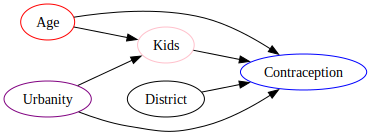

In [4]:
g = gr()
g.attr(rankdir="LR")
g.node(name="A", label="Age", color="red")
g.node(name="K", label="Kids", color="pink")
g.node(name="C", label="Contraception", color="blue")
g.node(name="D", label="District", color="black")
g.node(name="U", label="Urbanity", color="purple")
g.edge(tail_name="A", head_name="C")
g.edge(tail_name="A", head_name="K")
g.edge(tail_name="U", head_name="C")
g.edge(tail_name="D", head_name="C")
g.edge(tail_name="U", head_name="K")
g.edge(tail_name="K", head_name="C")
g

We want causal impact of $K$ on $C$ <br>
Fork: $C \leftarrow A \rightarrow K$, condition on $A$ to close fork <br>
Fork: $K \leftarrow U \rightarrow C$, condition on $U$ to close fork <br>
Since we district level variation the adjustment set is ${A, K, U, D}$ <br>
We will use non-centered model with a Bernoulli likelihood <br>
<center> $C \sim bernoulli(p) $</center>
<center> $p = invlogit(a_{D[i]} + b_{UD[i]}*U + bA*A + b_{KD[i]}*K) $</center>
<center> $a_{D[i]} \sim N(0,0.5) + \sigma * Z_{D[i]}$ </center>
<center> $Z_{D[i]} \sim N(0,1)$ </center>
<center> ... </center>

Plot the Contraception Rate

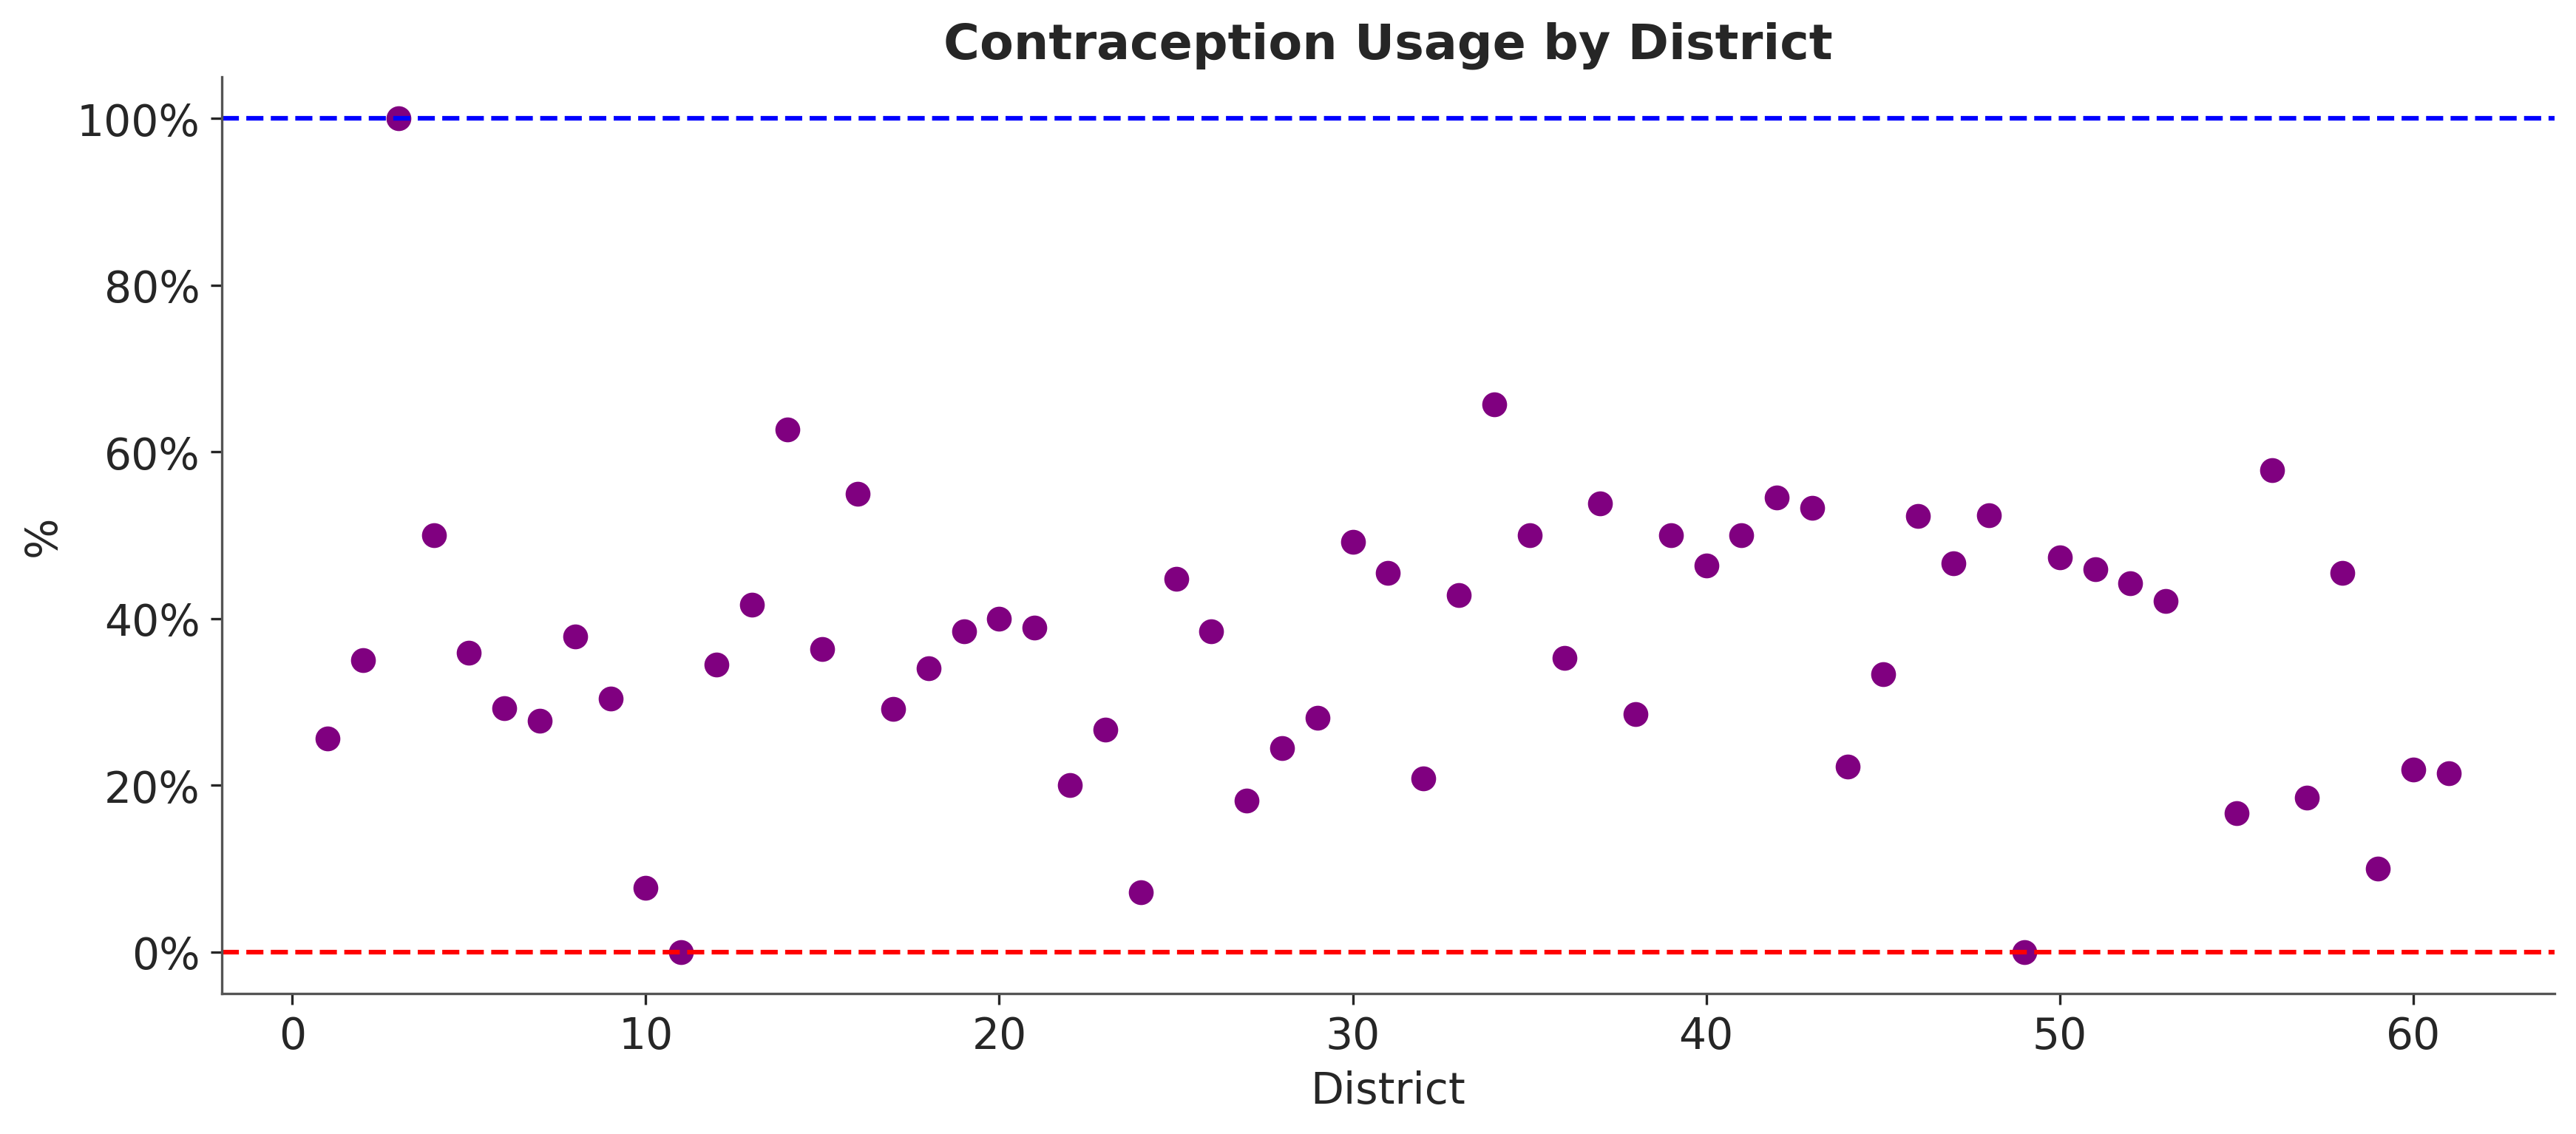

In [5]:
fig, ax = plt.subplots()

# Summarize counts and contraception use by district
summary_df = (
    df
    .groupby("district")
    .agg(
        {"woman": "count",
         "use.contraception": "mean"
        }
    )
    .rename(columns={"woman":"#", "use.contraception": "contraception usage"})
    .reset_index()
    .sort_values(by="district", ascending=True)
)
summary_df.plot(x="district", y="contraception usage", kind="scatter", ax=ax, s=50, color="purple")
ax.set_xlabel("District")
ax.set_ylabel("%")
ax.set_title("Contraception Usage by District")
ax.axhline(0, ls="--", color="red")
ax.axhline(1, ls="--", color="blue")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.show()

Begin Model for Causal Impact

In [6]:
df["K"] = df["living.children"].sub(1) # For indexing purposes only!
df["district_id"] = df["district"].sub(1) # For indexing purposes only!!

NDistricts = df["district"].max() # District begins counting at 1 so max is the number, note one district is missing!!!
KMax = df["K"].max()

In [7]:
def hw_b2(D:jnp.array = jnp.array(df["district_id"]), 
          U:jnp.array = jnp.array(df["urban"]),
          K:jnp.array = jnp.array(df["K"]),
          A:jnp.array = jnp.array(df["age.centered"]),
          C:jnp.array = jnp.array(df["use.contraception"])
         ) -> None:
    '''
    Numpyro model to measure causal effect of surviving kids (K) on contraception usage (C)
    Modeled with partial pooling by district level
    '''

    # Priors Z: non-centered
    with numpyro.plate("district", NDistricts) as district_plate:
        Z_a = numpyro.sample("Z_a", dist.Normal(0, 1))
        Z_U = numpyro.sample("Z_U", dist.Normal(0, 1))
        Z_K = numpyro.sample("Z_K", dist.Normal(0, 1))

    # Priors on sigma
    σ_a = numpyro.sample("σ_a", dist.Exponential(1.))
    σ_U = numpyro.sample("σ_U", dist.Exponential(1.))
    σ_K = numpyro.sample("σ_K", dist.Exponential(1.))

    a_bar = numpyro.sample("a_bar", dist.Normal(0., 0.5))
    u_bar = numpyro.sample("u_bar", dist.Normal(0., 0.5))
    k_bar = numpyro.sample("k_bar", dist.Normal(0., 0.5))

    # Non-centered coefficents
    a = a_bar + σ_a * Z_a
    bU = u_bar + σ_U * Z_U
    bK = k_bar + σ_K * Z_K

    # Coefficent for age not vary by district
    bA = numpyro.sample("bA", dist.Normal(0, 0.5))

    # Ordered effect on K
    ζ = numpyro.sample("ζ", dist.Dirichlet(jnp.ones(KMax)))
    η = jnp.concatenate([jnp.array([0.]), jnp.cumsum(ζ)])

    # μ
    μ = a[D] + bA*A + bU[D]*U + bK[D]*η[K]

    # Likelihood
    likelihood = numpyro.sample("likelihood", dist.Bernoulli(probs=expit(μ)), obs=C)
    

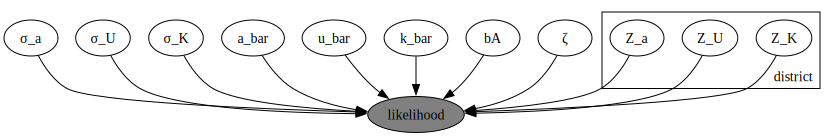

In [8]:
numpyro.render_model(hw_b2)

MCMC Sampling

In [9]:
rng_key = PRNGKey(seed)

# Split the key
rng_key, rng_subkey = split(rng_key)

mcmc = MCMC(NUTS(hw_b2), num_samples=2_000, num_warmup=2_000, num_chains=4)
mcmc.run(rng_subkey)

hw_b2_samples = mcmc.get_samples()

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

In [10]:
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
    Z_K[0]     -0.49      0.88     -0.50     -1.99      0.89   6506.61      1.00
    Z_K[1]      0.14      0.93      0.15     -1.47      1.62  11450.28      1.00
    Z_K[2]      0.08      0.98      0.09     -1.61      1.62  12101.19      1.00
    Z_K[3]      0.25      0.91      0.28     -1.26      1.73   9004.26      1.00
    Z_K[4]     -0.01      0.88     -0.01     -1.50      1.38  11612.02      1.00
    Z_K[5]     -0.24      0.87     -0.26     -1.60      1.24  10433.60      1.00
    Z_K[6]     -0.38      0.94     -0.39     -1.94      1.18  10207.20      1.00
    Z_K[7]      0.37      0.91      0.37     -1.07      1.91   7511.22      1.00
    Z_K[8]     -0.13      0.93     -0.13     -1.65      1.40  12785.34      1.00
    Z_K[9]     -0.33      0.99     -0.33     -1.99      1.27  10444.95      1.00
   Z_K[10]     -0.51      0.99     -0.52     -2.14      1.15   8282.43      1.00
   Z_K[11]     -0.48      0

In [11]:
idata = az.from_numpyro(
    posterior=mcmc
)

In [12]:
az.summary(idata, var_names=["ζ", "σ_a", "σ_U", "σ_K"], round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
ζ[0],0.79,0.09,0.62,0.96,0.00,0.0,8601.57,4400.87,1.0
ζ[1],0.14,0.09,0.00,0.29,0.00,0.0,8542.28,4720.83,1.0
ζ[2],0.07,0.06,0.00,0.17,0.00,0.0,11135.60,5681.15,1.0
σ_a,0.45,0.11,0.25,0.66,0.00,0.0,2086.34,2759.40,1.0
σ_U,0.51,0.22,0.05,0.89,0.01,0.0,1720.40,1733.67,1.0
σ_K,0.29,0.16,0.00,0.54,0.00,0.0,1169.17,2426.23,1.0


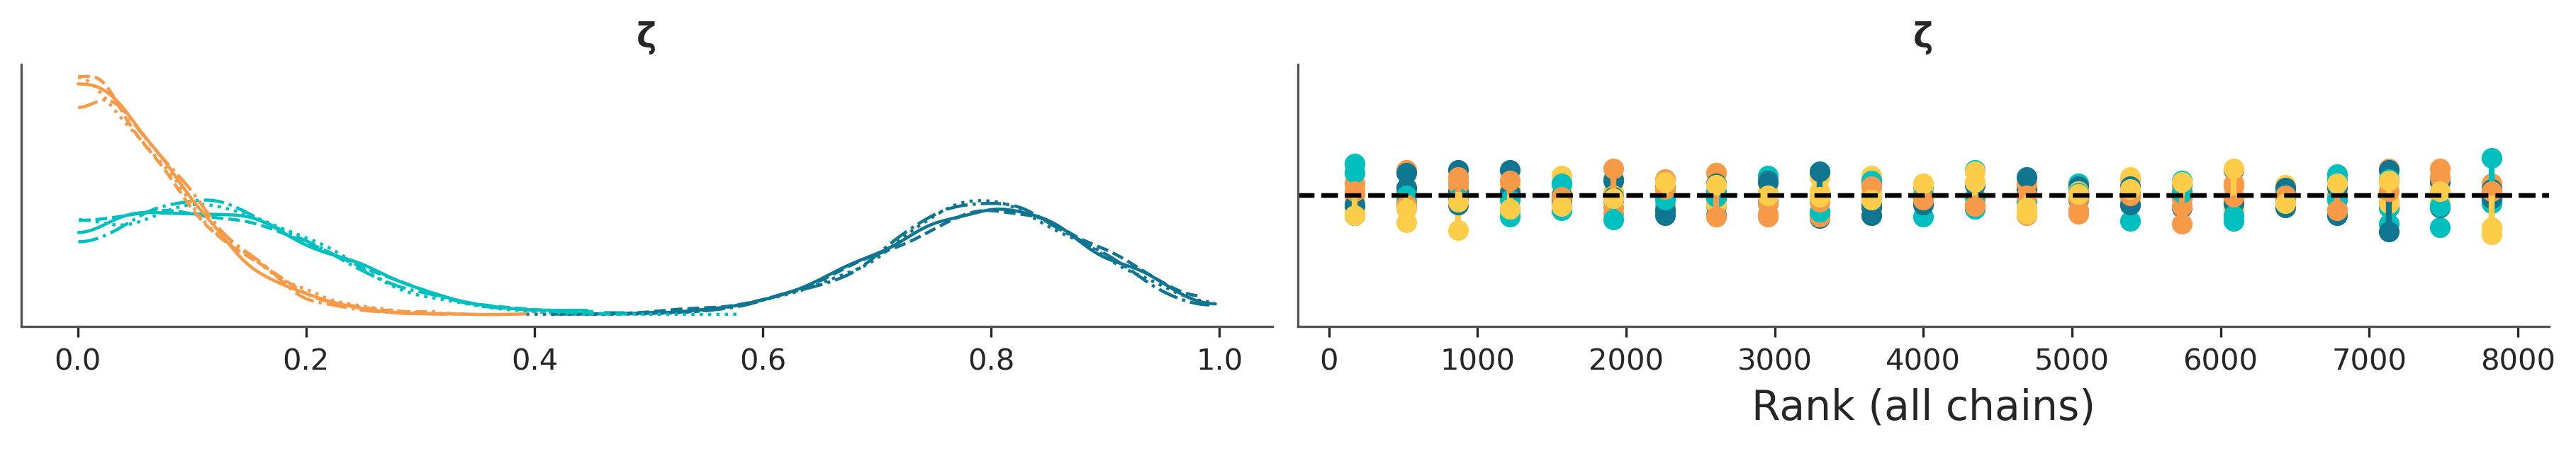

In [13]:
az.plot_trace(idata, var_names="ζ", kind="rank_vlines")
plt.show()

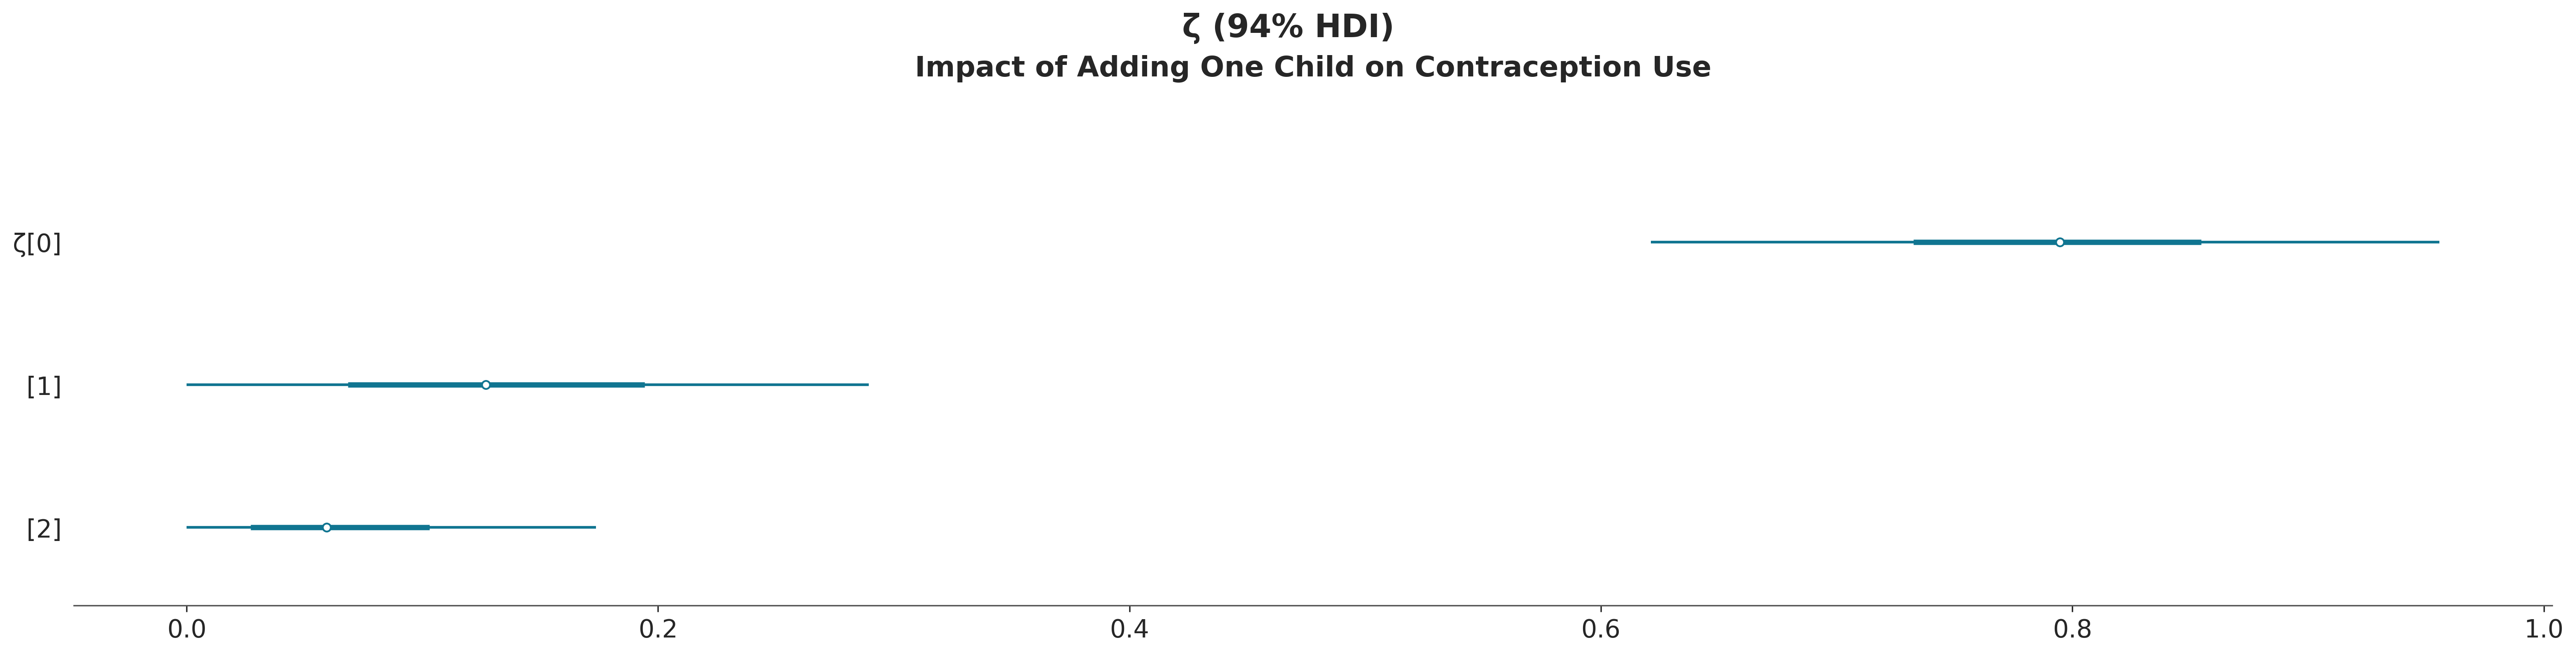

In [14]:
fig, ax = plt.subplots(figsize=(20., 5.))
az.plot_forest(
    idata,
    var_names="ζ",
    combined=True,
    kind="forestplot",
    ax=ax
)
plt.suptitle("ζ (94% HDI)")
ax.set_title("Impact of Adding One Child on Contraception Use")
plt.show()